In [7]:
!pip install -r ../requirements.txt

'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [8]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import f1_score,accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud
import langdetect
from langdetect import detect, detect_langs, DetectorFactory, LangDetectException
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import xgboost as xgb
from xgboost import XGBClassifier

import joblib
from lime.lime_text import LimeTextExplainer

import warnings
warnings.filterwarnings("ignore")

# Téléchargement des stopwords si ce n'est pas déjà fait
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yacinou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
# Lecture des données initiales
X_train_init = pd.read_csv("../data/X_train_update.csv", nrows=50000)
y_train_init = pd.read_csv("../data/Y_train_CVw08PX.csv", nrows=10000)
X_test_init = pd.read_csv("../data/X_test_update.csv", nrows=50000)

# Affichage des informations sur les datasets
print(f"Info X_train_init : {X_train_init.info()}")
print(f"\nInfo Y_train_init : {y_train_init.info()}")
print(f"\nInfo X_test_init : {X_test_init.info()}")

# Affichage des tailles des datasets
print(f"\nTaille X_train_init : {X_train_init.shape}")
print(f"\nTaille Y_train_init : {y_train_init.shape}")
print(f"\nTaille X_test_init : {X_test_init.shape}")

# Affichage du nombre de classes dans la variable cible
print(y_train_init['prdtypecode'].nunique())  # 27 classes

# Merge données d'entrainement dans le dataframe "full_data"
full_data = pd.merge(X_train_init, y_train_init, left_index=True, right_index=True)

# Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

# Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)  
full_data.set_index(['id'], inplace=True)

#Longueur des textes
full_data['len_designation'] = (full_data['designation'].astype(str).apply(len))
full_data['len_description'] = (full_data['description'].astype(str).apply(len))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   50000 non-null  int64 
 1   designation  50000 non-null  object
 2   description  32550 non-null  object
 3   productid    50000 non-null  int64 
 4   imageid      50000 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.9+ MB
Info X_train_init : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   10000 non-null  int64
 1   prdtypecode  10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB

Info Y_train_init : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Un

In [10]:
#Fonction de nettoyage du texte simple pour les colonnes de texte
import re

def clean_text(text):
    """
    Nettoyage de base du texte : suppression des balises HTML, des URLs, conversion en minuscules, suppression de la ponctuation et des chiffres.
    """
    if pd.isnull(text):
        return ""

    # Suppression des balises HTML
    text = re.sub(r'<.*?>', '', text)

    # Remplacement des <br /> par un espace
    text = text.replace(r'<br />', ' ')

    # Remplacement des référence de caractère HTML
    text = text.replace(r'&amp;', '&')
    text = text.replace(r'&nbsp;', ' ')
    text = text.replace(r'&lt', '<')
    text = text.replace(r'&gt', '>')
    text = text.replace(r'&quot', '"')
    text = text.replace(r'&#39', "'")
    text = text.replace(r'&eacute', 'e')
    text = text.replace(r'&egrave', 'e')
    text = text.replace(r'&ecirc', 'e')

    # Suppression des URLs et des liens  
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Conversion en minuscules
    text = text.lower()

    # Suppression des espaces supplémentaires
    text = re.sub(r'\s+', ' ', text).strip()

    # Suppression de la ponctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Suppression des chiffres
    text = re.sub(r'\d+', '', text)

    return text

In [11]:
# Nettoyage du texte
full_data['clean_designation'] = full_data['designation'].apply(clean_text)
full_data['clean_description'] = full_data['description'].apply(clean_text)

# Vérification de doublon dans les désignations et descriptions nettoyées
duplicate_designation = full_data['clean_designation'].duplicated().sum()
duplicate_description = full_data['clean_description'].duplicated().sum()

# Concaténation des désignations et descriptions nettoyées pour l'analyse de texte
full_data['text'] = full_data['clean_designation'] + ' ' + full_data['clean_description']

# Création d'un nouveau dataframe pour l'analyse de texte
clean_data = full_data.drop(columns=['designation', 'description', 'productid', 'imageid','clean_designation','clean_description','len_description', 'len_designation',], axis=1)

In [12]:
# Chargement des stopwords français et anglais
stop_fr = set(stopwords.words("french"))  # Stopwords français
stop_en = set(stopwords.words("english"))  # Stopwords anglais
stop_all = stop_fr.union(stop_en)  # Union des deux listes

# "Générique" est un terme générique et non discriminant pour différencier les classes de produits, on l'ajoute à la liste des stopwords
stop_all.add("générique")

def delete_stopwords(text):
    """
    Suppression des mots vides (stopwords)
    """
    return " ".join([w for w in text.split() if w not in stop_all and len(w) > 1])  # Garde mots > 1 caractère

# Application de la suppression des stopwords
clean_data["text_nostop"] = clean_data['text'].apply(delete_stopwords)  # Texte sans stopwords

# Stemming français (réduction des mots à leur racine)
stemmer = SnowballStemmer("french")  # Stemmer optimisé pour le français
def stem_text(text):
    """
    Application du stemming sur chaque mot (réduction à la racine)
    """
    return " ".join([stemmer.stem(w) for w in text.split()])  # Stemming mot par mot

# Application du stemming
clean_data["text_stem"] = clean_data["text_nostop"].apply(stem_text)  # Texte stemmé final

# Fin du processing textuel ci-dessus
# Début de la vectorisation + application des modèles ci-dessous

In [13]:
# Préparation des données pour l'analyse de texte
X = clean_data['text_nostop']
y = clean_data['prdtypecode']

# Encodage des labels de la variable cible avec LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Création des ensembles d'entraînement et de test pour l'analyse de texte (20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Initialisation de TfidfVectorizer avec des paramètres pour limiter le nombre de features et les n-grams
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Vectorisation du texte avec TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
# Création du Modèle XGBoost
xgb_clf = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    learning_rate=0.1,
    max_depth=8,
    n_estimators=600,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=-1
)

# Entraînement du modèle
xgb_clf.fit(
    X_train_tfidf,
    y_train,
    eval_set=[(X_test_tfidf, y_test)],
    verbose=50
)

# Prédictions + métriques pour évaluer les performances du modèle
y_pred = xgb_clf.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy       : {acc:.4f}")
print(f"F1 macro       : {f1_macro:.4f}")
print(f"F1 weighted    : {f1_weighted:.4f}")
print()
print(classification_report(y_test, y_pred, digits=3))

[0]	validation_0-mlogloss:2.88387
[50]	validation_0-mlogloss:1.28322
[100]	validation_0-mlogloss:1.16514
[150]	validation_0-mlogloss:1.13400
[200]	validation_0-mlogloss:1.12093
[250]	validation_0-mlogloss:1.11816
[300]	validation_0-mlogloss:1.12194
[350]	validation_0-mlogloss:1.12930
[400]	validation_0-mlogloss:1.13993
[450]	validation_0-mlogloss:1.14951
[500]	validation_0-mlogloss:1.15858
[550]	validation_0-mlogloss:1.16707
[599]	validation_0-mlogloss:1.17562
Accuracy       : 0.6930
F1 macro       : 0.6714
F1 weighted    : 0.6991

              precision    recall  f1-score   support

           0      0.249     0.623     0.356        77
           1      0.628     0.458     0.529        59
           2      0.730     0.600     0.659        45
           3      0.882     0.789     0.833        19
           4      0.596     0.517     0.554        60
           5      0.854     0.826     0.840        92
           6      0.556     0.294     0.385        17
           7      0.578     0

<Figure size 2400x2000 with 0 Axes>

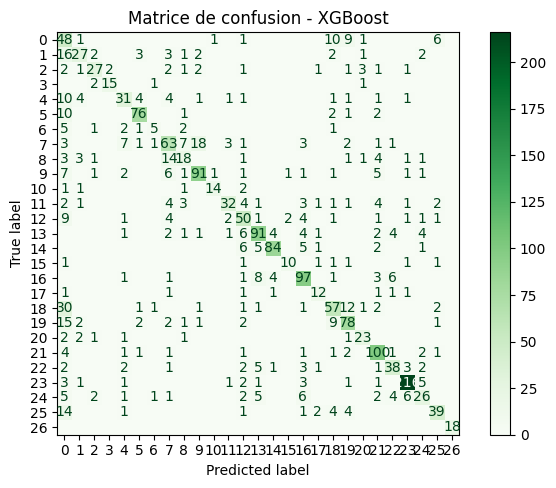

In [15]:
# Affichage de la matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(24,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap="Greens", values_format="d")

for text in disp.text_.flatten():
    if text.get_text() == "0":
        text.set_text("") # Supprime les annotations "0" pour une meilleure lisibilité

plt.title("Matrice de confusion - XGBoost")
plt.rcParams['font.size'] = 4
plt.savefig("../reports/figures/viz_txt_XGB_confusion.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

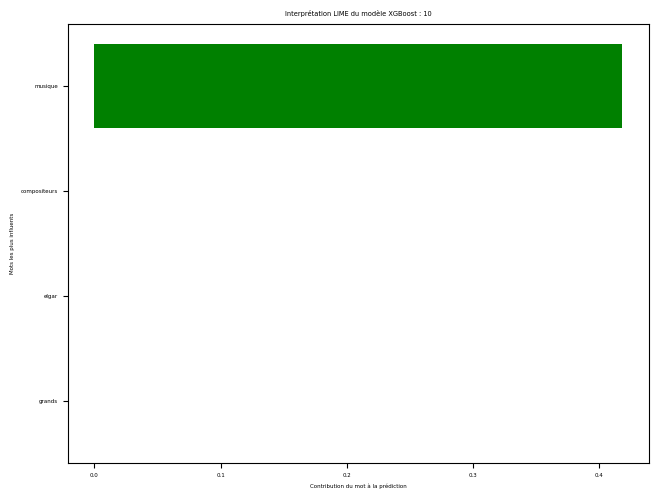

In [16]:
# Initialisation de LIME pour les explications du modèle XGBoost

def predict_proba_text(texts): # Fonction de prédiction de probabilité pour LIME, adaptée au format d'entrée de LIME
    return xgb_clf.predict_proba(tfidf.transform(texts))

# Récupération des noms de classes pour LIME
class_names = le.classes_.astype(str).tolist() # Récupération des noms de classes à partir du LabelEncoder pour LIME
explainer = LimeTextExplainer(class_names=class_names) # Initialisation de LIME avec les noms de classes

idx = 0 # Index du texte à expliquer dans l'ensemble de test
texte_a_expliquer = X_test.iloc[idx] # Récupération du texte à expliquer à partir de l'ensemble de test

# Explication de la prédiction pour le texte sélectionné
exp = explainer.explain_instance(
    texte_a_expliquer,
    predict_proba_text,
    num_features=10,
    top_labels=1
)

pred_class = xgb_clf.predict(tfidf.transform([texte_a_expliquer]))[0] # Prédiction de la classe pour le texte sélectionné
pred_label = le.inverse_transform([pred_class])[0] # Récupération du nom de la classe prédite à partir de l'index de classe

# Affichage de l'explication LIME pour la classe prédite
fig = exp.as_pyplot_figure(label=pred_class)
plt.title(f"Interprétation LIME du modèle XGBoost : {pred_label}")
plt.tight_layout()
plt.xlabel("Contribution du mot à la prédiction")
plt.ylabel("Mots les plus influents")
plt.savefig("../reports/figures/lime_XGB_interpretation.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
joblib.dump(xgb_clf, "../models/xgb_text_model.joblib")

['../models/xgb_text_model.joblib']